# 15 - Error Analysis

## Objective

This notebook investigates the prediction errors produced by the final Full Multimodal XGBoost classifier.

The objectives are to:

- identify incorrectly classified participants;
- characterize the distribution of prediction errors across diagnostic classes;
- evaluate prediction confidence for correct and incorrect classifications;
- summarize representative misclassification patterns.

This analysis complements the overall model evaluation by highlighting situations where the classifier experiences greater uncertainty.

In [2]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [3]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs" / "error_analysis"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(ROOT)

c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease


In [4]:
MODEL_PATH = MODEL_DIR / "full_multimodal_xgboost.joblib"
TEST_PATH = DATA_DIR / "test_multimodal_full_task_aware.csv"
model = joblib.load(MODEL_PATH)
test_df = pd.read_csv(TEST_PATH)
X_test = test_df[model.feature_names_in_]
y_test = test_df["label"]
print(X_test.shape)

(71, 2405)


## Generate predictions

In [5]:
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)
confidence = probabilities.max(axis=1)

## Prediction Summary

Predictions generated by the final Full Multimodal XGBoost classifier are evaluated on the independent participant-level test set.

Prediction confidence is defined as the highest predicted probability assigned to any diagnostic class.

In [6]:
results = pd.DataFrame({
    "patient_id": test_df["patient_id"],
    "true_label": y_test,
    "predicted_label": predictions,
    "confidence": confidence,
})
results["correct"] = (
    results.true_label == results.predicted_label
)
results.head()

,patient_id,true_label,predicted_label,confidence,correct
0,18,2,1,0.904193,False
1,25,1,1,0.991225,True
2,28,1,1,0.630845,True
3,43,2,1,0.678255,False
4,51,1,2,0.654599,False


In [7]:
results.correct.value_counts()

correct
True     51
False    20
Name: count, dtype: int64

## Overall Prediction Performance

The final Full Multimodal XGBoost classifier correctly classified 51 of the 71 participants in the independent participant-level test set, resulting in an overall accuracy of 71.8%.

The remaining 20 participants were incorrectly classified and were further analyzed to identify common error patterns, prediction confidence, and class-specific misclassification trends.

## Misclassified Participants

Incorrectly classified participants are summarized below.

In [8]:
errors = results.loc[~results.correct]
errors

,patient_id,true_label,predicted_label,confidence,correct
0,18,2,1,0.904193,False
3,43,2,1,0.678255,False
4,51,1,2,0.654599,False
11,74,1,2,0.469368,False
12,80,0,1,0.849166,False
19,140,2,0,0.725733,False
20,148,0,1,0.629555,False
21,153,0,1,0.733551,False
23,161,2,1,0.903362,False
25,167,0,2,0.563456,False


In [9]:
errors.to_csv(
    TABLES_DIR / "misclassified_participants.csv",
    index=False,
)

Representative examples of incorrect predictions include participants originally diagnosed with Other Movement Disorders that were predicted as Parkinson's Disease with high confidence, as well as Healthy Controls classified as Parkinson's Disease.

These cases suggest that overlapping clinical characteristics remain an important challenge for automated multiclass screening.

## Prediction Confidence

Prediction confidence is compared between correctly and incorrectly classified participants.

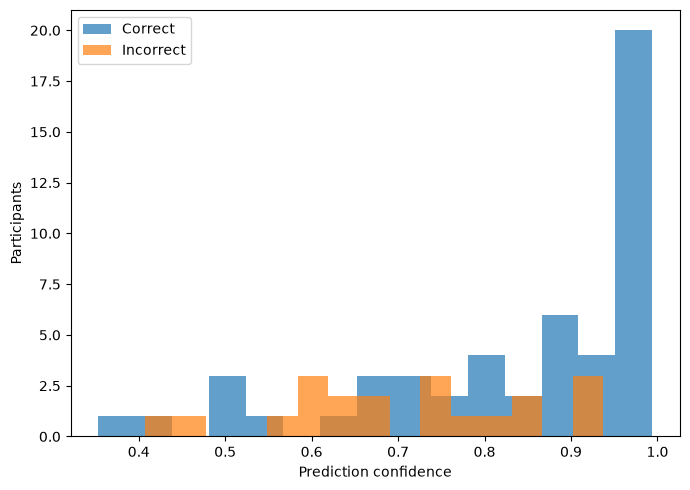

In [10]:
correct = results[results["correct"]]["confidence"]
incorrect = results[~results["correct"]]["confidence"]

plt.figure(figsize=(7,5))

plt.hist(correct, bins=15, alpha=0.7, label="Correct")

plt.hist(incorrect, bins=15, alpha=0.7, label="Incorrect")

plt.xlabel("Prediction confidence")
plt.ylabel("Participants")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "prediction_confidence.png",
    dpi=300,
)
plt.show()

## Prediction Confidence

Prediction confidence was compared between correctly and incorrectly classified participants.

Correct predictions generally exhibited higher confidence scores, with many participants assigned probabilities above 0.90.

Incorrect predictions tended to occur at lower confidence levels; however, several misclassified participants were associated with relatively high confidence values. These high-confidence errors suggest that certain participants present movement patterns and non-motor symptom profiles that closely resemble those of another diagnostic group rather than reflecting purely uncertain predictions.

## Misclassification Patterns

The confusion matrix summarizes the distribution of classification errors across diagnostic classes.

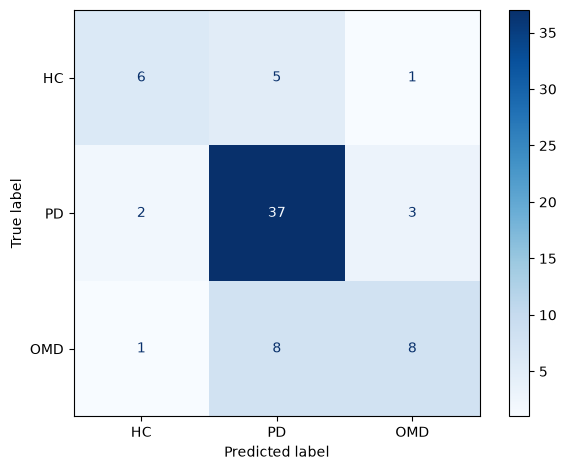

In [11]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["HC", "PD", "OMD"],
    cmap="Blues",
    values_format="d",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "error_confusion_matrix.png",
    dpi=300,
)

plt.show()

In [12]:
report = classification_report(
    y_test,
    predictions,
    output_dict=True,
)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0,0.666667,0.500000,0.571429,12.00000
1,0.740000,0.880952,0.804348,42.00000
2,0.666667,0.470588,0.551724,17.00000
accuracy,0.718310,0.718310,0.718310,0.71831
macro avg,0.691111,0.617180,0.642500,71.00000
weighted avg,0.710047,0.718310,0.704494,71.00000


In [13]:
report_df.to_csv(
    TABLES_DIR / "classification_report.csv",
    index=True,
)

## Misclassification Patterns

Figure XX presents the confusion matrix obtained on the independent participant-level test set.

Parkinson's Disease exhibited the highest classification performance, with 37 of 42 participants correctly identified.

Healthy Controls achieved moderate performance, with 6 of 12 participants correctly classified, while five participants were incorrectly predicted as Parkinson's Disease and one as Other Movement Disorders.

The greatest challenge was observed for the Other Movement Disorders class. Although eight participants were correctly classified, eight additional participants were incorrectly predicted as Parkinson's Disease, reflecting the clinical heterogeneity of this diagnostic group.

## Lowest-Confidence Predictions

The participants associated with the lowest prediction confidence are examined because they represent the highest degree of model uncertainty.

In [14]:
results.sort_values(
    "confidence"
).head(15)

,patient_id,true_label,predicted_label,confidence,correct
33,195,2,2,0.353274,True
57,359,2,1,0.407419,False
52,335,0,0,0.411801,True
11,74,1,2,0.469368,False
67,420,0,0,0.489608,True
17,130,2,2,0.492199,True
50,331,1,1,0.517661,True
30,189,1,1,0.538018,True
25,167,0,2,0.563456,False
45,295,0,1,0.586257,False


## High-Confidence Misclassifications

Incorrect predictions associated with high confidence may indicate systematic overlap between diagnostic groups.

In [15]:
errors.sort_values(
    "confidence",
    ascending=False,
).head(15)

,patient_id,true_label,predicted_label,confidence,correct
26,168,2,1,0.937421,False
0,18,2,1,0.904193,False
23,161,2,1,0.903362,False
39,246,1,2,0.852821,False
12,80,0,1,0.849166,False
34,213,2,1,0.797525,False
44,291,2,1,0.790696,False
31,191,2,1,0.759880,False
21,153,0,1,0.733551,False
19,140,2,0,0.725733,False


Representative examples of incorrect predictions include participants originally diagnosed with Other Movement Disorders that were predicted as Parkinson's Disease with high confidence, as well as Healthy Controls classified as Parkinson's Disease.

These cases suggest that overlapping clinical characteristics remain an important challenge for automated multiclass screening.

In [16]:
results.to_csv(
    TABLES_DIR / "prediction_results.csv",
    index=False,
)
print("Saved outputs")
print(TABLES_DIR)
print(FIGURES_DIR)

Saved outputs
c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\error_analysis\tables
c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\error_analysis\figures


## Error Analysis Summary

The majority of prediction errors involved confusion between Parkinson's Disease and Other Movement Disorders, consistent with the heterogeneous clinical presentation of movement disorders included in the dataset.

Healthy Controls were occasionally classified as Parkinson's Disease, particularly for participants exhibiting movement characteristics similar to early Parkinsonian symptoms.

Although incorrect predictions generally exhibited lower confidence than correct classifications, several high-confidence errors were also observed, indicating that certain participants possess feature profiles strongly resembling another diagnostic class.

Overall, the error analysis supports the interpretation that the proposed multimodal framework performs reliably while highlighting the inherent difficulty of distinguishing clinically overlapping neurological conditions.